In [1]:
import bilby
from bilby.core.utils import random
import numpy as np
from bilby.core.prior.joint import JointPrior
from scipy.stats import gaussian_kde

from converse_likelihood import EOSHyperparameterLikelihood, _build_family
from KDEPrior import KDEJointDist
from bilby.gw.utils import lalsim_SimNeutronStarMaximumMass
from bilby.gw.conversion import solar_mass

random.seed(123)


In [2]:
outdir = "outdir"
bilby.utils.check_directory_exists_and_if_not_mkdir(outdir)

In [3]:
# ---------- load event-level results ----------
data = np.load('50_runs_test.npz')

covs = data['covs'].astype(np.float64)   # (N, 2, 2)
# covs = np.array([(c + c.T) / 2 + 1e-10 * np.eye(2) for c in covs])
means = data['means']                    # (N, 2)

# ---------- EOS / prior setup ----------
log10_p1_cgs = 35.293288373856534
log10_p2_cgs = 35.648689969687915
causal = False

mmin = 1.0
mmax = 2.0

# injection truth (for reference only)
param1_true = 4.183994058757201
param2_true = 3.168076721819637
param3_true = 1.300271383168368

viable = np.load('viable_gamma_samples.npy')
kde = gaussian_kde(viable.T, bw_method='scott')


In [4]:
hp_likelihood = EOSHyperparameterLikelihood(
    cov_matrices=covs,
    means=means,
    mass_min=mmin,
    mass_max=mmax,
    log10_pressure1_cgs=log10_p1_cgs,
    log10_pressure2_cgs=log10_p2_cgs,
    causal=causal,
)

In [5]:
# Prior bounds must match is_viable / KDE support
BOUNDS = [(2.7, 5.0), (1.0, 5.0), (1.0, 2.31)]

dist = KDEJointDist(
    names=["param1", "param2", "param3"],
    kde=kde,
    bounds=BOUNDS,
)

priors = {
    "param1": JointPrior(dist=dist, name="param1", latex_label=r"$\Gamma_0$"),
    "param2": JointPrior(dist=dist, name="param2", latex_label=r"$\Gamma_1$"),
    "param3": JointPrior(dist=dist, name="param3", latex_label=r"$\Gamma_2$"),
}

In [6]:
MIN_MAX_MASS = 2.0  # M☉ — minimum allowed maximum NS mass

def is_viable(g0, g1, g2):
    """Return True iff (g0, g1, g2) defines a physically acceptable EOS
    that supports a maximum NS mass of at least MIN_MAX_MASS.
    Reuses _build_family so viability logic stays in one place.
    """
    family = _build_family(g0, log10_p1_cgs, g1, log10_p2_cgs, g2, int(causal))
    if family is None:
        return False
    return lalsim_SimNeutronStarMaximumMass(family) / solar_mass >= MIN_MAX_MASS


/Users/ved/miniforge3/envs/neutron/lib/python3.12/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
12:26 bilby INFO    : Running for label 'eos_hierarchical', output will be saved to 'outdir'
12:26 bilby INFO    : Analysis priors:
12:26 bilby INFO    : param1=JointPrior(dist=KDEJointDist(names=['param1', 'param2', 'param3'], kde=<scipy.stats._kde.gaussian_kde object at 0x13a604bf0>, bounds={'param1': (2.7, 5.0), 'para

  0%|          | 0/5000 [00:00<?, ?it/s]

12:37 bilby INFO    : Checkpointing sampler to file outdir/emcee_eos_hierarchical/sampler.pickle
12:37 bilby INFO    : Starting to close worker pool.
12:37 bilby INFO    : Finished closing worker pool.
12:37 bilby INFO    : Max autocorr time = 45
12:37 bilby INFO    : Discarding 135 steps for burn-in
12:37 bilby INFO    : Sampling time: 0:11:22.763518
12:37 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
12:37 bilby ERROR   : 

Saving the data has failed with the following message:
Object of type gaussian_kde is not JSON serializable
Data has been dumped to outdir/eos_hierarchical_result.pkl.


12:37 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
12:37 bilby ERROR   : 

Saving the data has failed with the followin

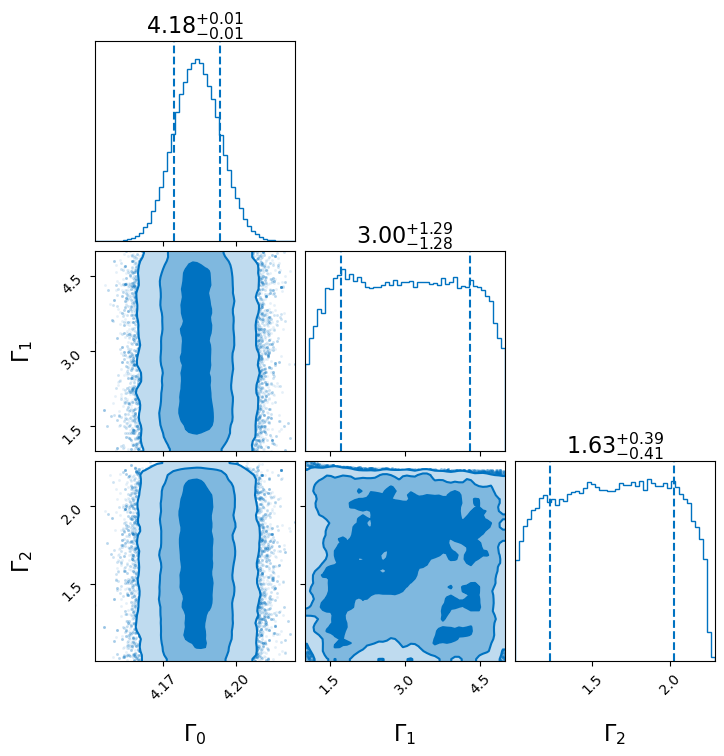

In [7]:
n_walkers = 64

lo = np.array([b[0] for b in BOUNDS])
hi = np.array([b[1] for b in BOUNDS])

init_pos = []
while len(init_pos) < n_walkers:
    batch = kde.resample(n_walkers * 10).T          # (10*n_walkers, 3)
    in_bounds = np.all((batch >= lo) & (batch <= hi), axis=1)
    for candidate in batch[in_bounds]:
        if len(init_pos) >= n_walkers:
            break
        if is_viable(*candidate):
            init_pos.append(candidate)

init_pos = np.array(init_pos)  # (n_walkers, 3)

result = bilby.run_sampler(
    likelihood=hp_likelihood,
    priors=priors,
    sampler="emcee",
    nwalkers=n_walkers,
    nsteps=5000,
    pos0=init_pos,
    outdir=outdir,
    label="eos_hierarchical",
    npool=10
)

result.plot_corner()
